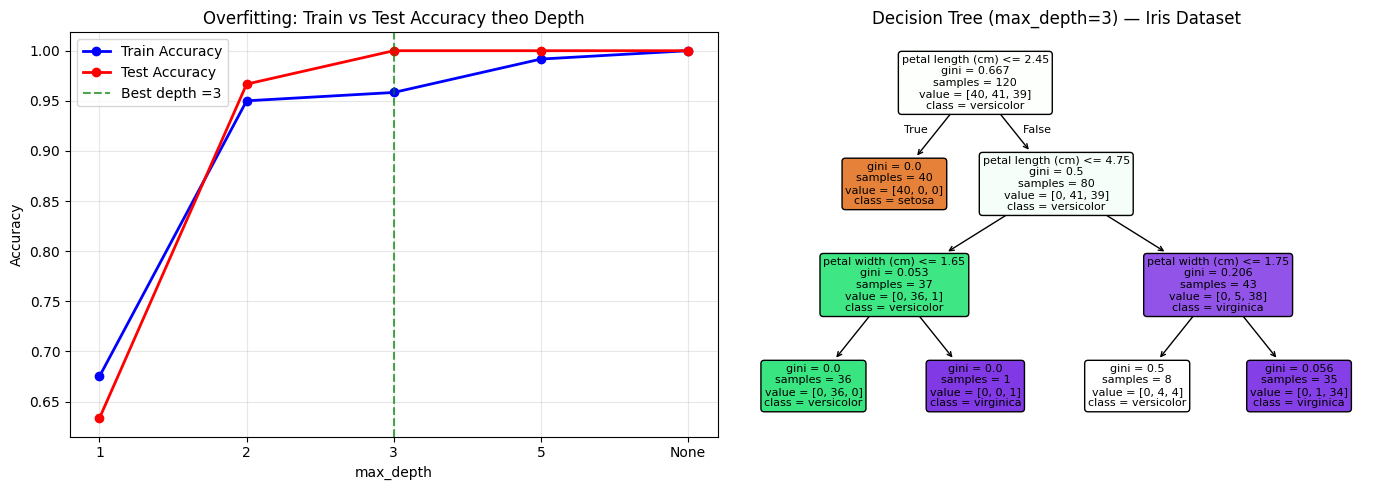

Text representation của tree:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2


Depth        Train Acc    Test Acc       Gap
--------------------------------------------
1               0.6750      0.6333    0.0417
2               0.9500      0.9667   -0.0167
3               0.9583      1.0000   -0.0417
5               0.9917      1.0000   -0.0083
None            1.0000      1.0000    0.0000


In [1]:
# ============================================================
# BÀI TẬP 2: Vẽ và Hiểu Decision Tree
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load Iris dataset (bài toán phân loại đơn giản, 3 class)
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- So sánh depth khác nhau ---
depths = [1, 2, 3, 5, None]
train_accs, test_accs = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs.append(accuracy_score(y_test, tree.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Accuracy vs Depth
depth_labels = [str(d) if d else 'None' for d in depths]
x = range(len(depths))
axes[0].plot(x, train_accs, 'b-o', label='Train Accuracy', linewidth=2)
axes[0].plot(x, test_accs,  'r-o', label='Test Accuracy', linewidth=2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(depth_labels)
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Overfitting: Train vs Test Accuracy theo Depth")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Đánh dấu sweet spot
best_idx = test_accs.index(max(test_accs))
axes[0].axvline(x=best_idx, color='green', linestyle='--', alpha=0.7,
                label=f'Best depth ={depths[best_idx]}')
axes[0].legend()

# Chart 2: Vẽ tree với depth=3
best_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
best_tree.fit(X_train, y_train)

plot_tree(best_tree, feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True, ax=axes[1],
          fontsize=8)
axes[1].set_title("Decision Tree (max_depth=3) — Iris Dataset")

plt.tight_layout()
plt.savefig("bai_tap_2_decision_tree.png", dpi=150, bbox_inches='tight')
plt.show()

# In text representation
print("Text representation của tree:")
print(export_text(best_tree, feature_names=iris.feature_names))

# In kết quả từng depth
print(f"\n{'Depth':<10}{'Train Acc':>12}{'Test Acc':>12}{'Gap':>10}")
print("-" * 44)
for d, tr, te in zip(depth_labels, train_accs, test_accs):
    gap = tr - te
    flag = " ← overfit!" if gap > 0.05 else ""
    print(f"{d:<10}{tr:>12.4f}{te:>12.4f}{gap:>10.4f}{flag}")

Features:['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_encoded', 'family_size', 'is_alone', 'embarked_Q', 'embarked_S']
Train:712 | Test:179

--- Decision Tree: Ảnh hưởng của max_depth ---
Depth    Train Acc  Test Acc      F1     AUC
--------------------------------------------
2           0.8048    0.7598  0.5905  0.7698
3           0.8287    0.8045  0.7200  0.8275
5           0.8638    0.7598  0.6504  0.8038 ← overfit!
7           0.8876    0.7821  0.6667  0.7919 ← overfit!
10          0.9284    0.7765  0.6875  0.7574 ← overfit!
None        0.9817    0.7989  0.7353  0.7760 ← overfit!

Best DT: max_depth =None

--- Random Forest: Ảnh hưởng của n_estimators ---
N trees    Train Acc  Test Acc      F1     AUC
------------------------------------------------
10            0.9705    0.8045  0.7328  0.8378
50            0.9803    0.8212  0.7647  0.8433
100           0.9817    0.8156  0.7556  0.8338
200           0.9817    0.8156  0.7519  0.8299
500           0.9817    0.8156  0.7519  0.8

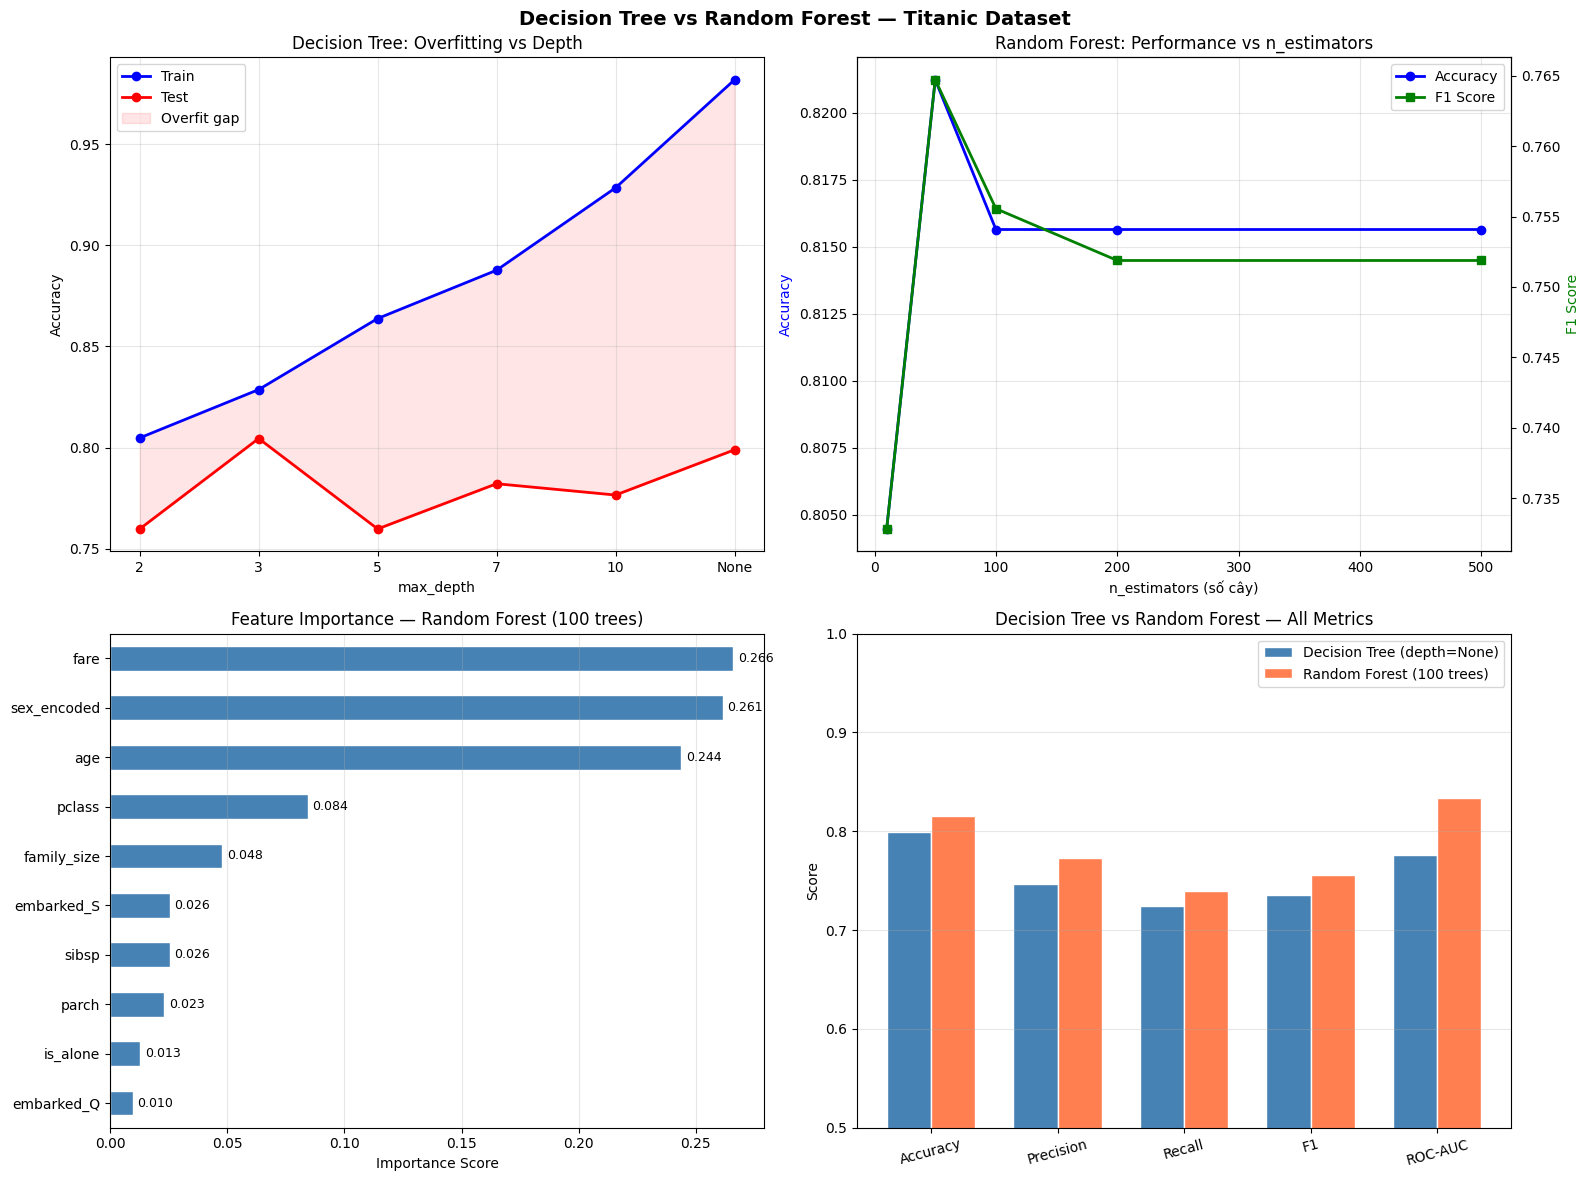

In [2]:
# ============================================================
# BÀI TẬP 3: Decision Tree vs Random Forest — Titanic
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# ============================================================
# BƯỚC 1: Load và Preprocess Titanic
# ============================================================
df = sns.load_dataset('titanic')

# Chọn features và xử lý
df_model = df[['survived', 'pclass', 'sex', 'age',
               'sibsp', 'parch', 'fare', 'embarked']].copy()

df_model['age']      = df_model['age'].fillna(df_model['age'].median())
df_model['fare']     = df_model['fare'].fillna(df_model['fare'].median())
df_model['embarked'] = df_model['embarked'].fillna(df_model['embarked'].mode()[0])

# Feature Engineering
df_model['sex_encoded'] = (df_model['sex'] == 'female').astype(int)
df_model['family_size'] = df_model['sibsp'] + df_model['parch']
df_model['is_alone']    = (df_model['family_size'] == 0).astype(int)
df_model = pd.get_dummies(df_model, columns=['embarked'], drop_first=True)
df_model = df_model.drop(columns=['sex'])

X = df_model.drop(columns=['survived'])
y = df_model['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Features:{list(X.columns)}")
print(f"Train:{X_train.shape[0]} | Test:{X_test.shape[0]}")

# ============================================================
# BƯỚC 2: Decision Tree — thử nhiều max_depth
# ============================================================
print("\n--- Decision Tree: Ảnh hưởng của max_depth ---")
print(f"{'Depth':<8}{'Train Acc':>10}{'Test Acc':>10}{'F1':>8}{'AUC':>8}")
print("-" * 44)

dt_results = {}
for depth in [2, 3, 5, 7, 10, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    tr_pred = dt.predict(X_train)
    te_pred = dt.predict(X_test)
    te_prob = dt.predict_proba(X_test)[:, 1]

    result = {
        'train_acc': accuracy_score(y_train, tr_pred),
        'test_acc':  accuracy_score(y_test, te_pred),
        'f1':        f1_score(y_test, te_pred),
        'auc':       roc_auc_score(y_test, te_prob),
        'model':     dt
    }
    dt_results[depth] = result
    flag = " ← overfit!" if result['train_acc'] - result['test_acc'] > 0.07 else ""
    label = str(depth) if depth else 'None'
    print(f"{label:<8}{result['train_acc']:>10.4f}{result['test_acc']:>10.4f}"
          f"{result['f1']:>8.4f}{result['auc']:>8.4f}{flag}")

# Best Decision Tree
best_depth = max(dt_results, key=lambda d: dt_results[d]['f1'])
best_dt = dt_results[best_depth]['model']
print(f"\nBest DT: max_depth ={best_depth}")

# ============================================================
# BƯỚC 3: Random Forest — thử nhiều n_estimators
# ============================================================
print("\n--- Random Forest: Ảnh hưởng của n_estimators ---")
print(f"{'N trees':<10}{'Train Acc':>10}{'Test Acc':>10}{'F1':>8}{'AUC':>8}")
print("-" * 48)

rf_results = {}
for n in [10, 50, 100, 200, 500]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    tr_pred = rf.predict(X_train)
    te_pred = rf.predict(X_test)
    te_prob = rf.predict_proba(X_test)[:, 1]

    result = {
        'train_acc': accuracy_score(y_train, tr_pred),
        'test_acc':  accuracy_score(y_test, te_pred),
        'f1':        f1_score(y_test, te_pred),
        'auc':       roc_auc_score(y_test, te_prob),
        'model':     rf
    }
    rf_results[n] = result
    print(f"{n:<10}{result['train_acc']:>10.4f}{result['test_acc']:>10.4f}"
          f"{result['f1']:>8.4f}{result['auc']:>8.4f}")

best_rf = rf_results[100]['model']  # 100 trees thường là sweet spot

# ============================================================
# BƯỚC 4: Bảng so sánh cuối cùng
# ============================================================
print("\n" + "=" * 60)
print("BẢNG SO SÁNH: Decision Tree vs Random Forest")
print("=" * 60)

def metrics_row(name, model, X, y):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]
    return {
        'Model': name,
        'Accuracy':  accuracy_score(y, pred),
        'Precision': precision_score(y, pred),
        'Recall':    recall_score(y, pred),
        'F1':        f1_score(y, pred),
        'ROC-AUC':   roc_auc_score(y, prob),
    }

rows = [
    metrics_row(f"Decision Tree (depth={best_depth})", best_dt, X_test, y_test),
    metrics_row("Random Forest (100 trees)", best_rf, X_test, y_test),
]
results_df = pd.DataFrame(rows).set_index('Model')
print(results_df.round(4))

print("""
💬 Nhận xét:
  • Random Forest hầu như luôn tốt hơn Decision Tree đơn lẻ
  • DT overfit rõ (train acc >> test acc) khi depth lớn
  • RF ổn định hơn nhờ bagging + feature randomness
  • Đánh đổi: RF không giải thích được như DT
""")

# ============================================================
# BƯỚC 5: Visualization
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: DT — Train vs Test Accuracy theo depth
depths_plot   = [d for d in dt_results]
depth_labels  = [str(d) if d else 'None' for d in depths_plot]
train_accs_dt = [dt_results[d]['train_acc'] for d in depths_plot]
test_accs_dt  = [dt_results[d]['test_acc']  for d in depths_plot]

axes[0,0].plot(depth_labels, train_accs_dt, 'b-o', lw=2, label='Train')
axes[0,0].plot(depth_labels, test_accs_dt,  'r-o', lw=2, label='Test')
axes[0,0].fill_between(range(len(depths_plot)),
                        train_accs_dt, test_accs_dt,
                        alpha=0.1, color='red', label='Overfit gap')
axes[0,0].set_xlabel("max_depth")
axes[0,0].set_ylabel("Accuracy")
axes[0,0].set_title("Decision Tree: Overfitting vs Depth")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Chart 2: RF — Test Accuracy & F1 theo n_estimators
n_trees  = list(rf_results.keys())
rf_accs  = [rf_results[n]['test_acc'] for n in n_trees]
rf_f1s   = [rf_results[n]['f1']       for n in n_trees]

ax2b = axes[0,1].twinx()
axes[0,1].plot(n_trees, rf_accs, 'b-o', lw=2, label='Accuracy')
ax2b.plot(n_trees, rf_f1s, 'g-s', lw=2, label='F1 Score')
axes[0,1].set_xlabel("n_estimators (số cây)")
axes[0,1].set_ylabel("Accuracy", color='blue')
ax2b.set_ylabel("F1 Score", color='green')
axes[0,1].set_title("Random Forest: Performance vs n_estimators")
axes[0,1].grid(True, alpha=0.3)
lines1, labels1 = axes[0,1].get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
axes[0,1].legend(lines1 + lines2, labels1 + labels2)

# Chart 3: Feature Importance (Random Forest)
fi = pd.Series(best_rf.feature_importances_, index=X.columns)
fi_sorted = fi.sort_values(ascending=True)

fi_sorted.plot(kind='barh', ax=axes[1,0], color='steelblue', edgecolor='white')
axes[1,0].set_title("Feature Importance — Random Forest (100 trees)")
axes[1,0].set_xlabel("Importance Score")
axes[1,0].grid(True, alpha=0.3, axis='x')

# Thêm giá trị vào bar
for i, v in enumerate(fi_sorted):
    axes[1,0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

# Chart 4: So sánh metrics DT vs RF
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
dt_vals = results_df.loc[f"Decision Tree (depth={best_depth})"].values
rf_vals = results_df.loc["Random Forest (100 trees)"].values

x_pos = np.arange(len(metrics_names))
width = 0.35
axes[1,1].bar(x_pos - width/2, dt_vals, width, label=f'Decision Tree (depth={best_depth})',
              color='steelblue', edgecolor='white')
axes[1,1].bar(x_pos + width/2, rf_vals, width, label='Random Forest (100 trees)',
              color='coral', edgecolor='white')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(metrics_names, rotation=15)
axes[1,1].set_ylabel("Score")
axes[1,1].set_title("Decision Tree vs Random Forest — All Metrics")
axes[1,1].legend()
axes[1,1].set_ylim(0.5, 1.0)
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle("Decision Tree vs Random Forest — Titanic Dataset",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("bai_tap_3_dt_vs_rf.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# BÀI TẬP 3: Pipeline đầy đủ — xử lý mixed data types
# ============================================================

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score

# --- Tạo dataset mô phỏng có mixed types và missing values ---
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'age':        np.random.randint(20, 70, n).astype(float),
    'income':     np.random.normal(50000, 20000, n),
    'score':      np.random.uniform(300, 850, n),
    'gender':     np.random.choice(['M', 'F'], n),
    'education':  np.random.choice(['HS', 'Bachelor', 'Master', 'PhD'], n),
    'region':     np.random.choice(['North', 'South', 'East', 'West'], n),
})

# Thêm missing values
for col in ['age', 'income', 'gender']:
    mask = np.random.rand(n) < 0.08
    df.loc[mask, col] = np.nan

# Tạo target
score = (
    (df['income'].fillna(50000) - 50000) / 20000 * 0.5
    + (df['age'].fillna(40) - 40) / 20 * 0.3
    + (df['education'].map({'HS': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}).fillna(1)) * 0.3
    + np.random.normal(0, 0.5, n)
)
df['target'] = (score > score.median()).astype(int)

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape:{X_train.shape}")
print(f"Missing values in train:\n{X_train.isnull().sum()}")

# --- Xây Pipeline ---
numeric_features     = ['age', 'income', 'score']
categorical_features = ['gender', 'education', 'region']

# Numeric: impute median → scale
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Categorical: impute mode → one-hot encode
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')),
])

# Kết hợp
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

# Full pipeline với 2 model khác nhau
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(C=1.0, max_iter=1000))
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# --- Train và evaluate ---
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

for name, pipe in [('Logistic Regression', lr_pipeline),
                   ('Random Forest',       rf_pipeline)]:
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    cv_f1  = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')

    print(f"\n{name}:")
    print(f"  Test F1      ={f1_score(y_test, y_pred):.4f}")
    print(f"  Test AUC     ={roc_auc_score(y_test, y_prob).mean():.4f}")
    print(f"  CV F1        ={cv_f1.mean():.4f} ±{cv_f1.std():.4f}")

# --- Predict data mới (không cần manual preprocessing!) ---
new_employee = pd.DataFrame({
    'age': [35], 'income': [65000], 'score': [720],
    'gender': ['M'], 'education': ['Master'], 'region': ['North']
})
pred = lr_pipeline.predict(new_employee)[0]
prob = lr_pipeline.predict_proba(new_employee)[0, 1]
print(f"\nDự đoán nhân viên mới:{'Positive' if pred else 'Negative'} (p={prob:.2%})")

# ============================================================
# NHẬN XÉT (viết sau khi chạy)
# ============================================================
# CV F1 và Test F1 có gần nhau không? → [điền]
# LR vs RF: Model nào tốt hơn? Tại sao có thể? → [điền]
# Pipeline giải quyết vấn đề gì so với làm thủ công? → [điền]

Train shape:(800, 6)
Missing values in train:
age          61
income       79
score         0
gender       70
education     0
region        0
dtype: int64

Logistic Regression:
  Test F1      =0.8061
  Test AUC     =0.8916
  CV F1        =0.8024 ±0.0272

Random Forest:
  Test F1      =0.7857
  Test AUC     =0.8524
  CV F1        =0.7671 ±0.0301

Dự đoán nhân viên mới:Positive (p=65.60%)


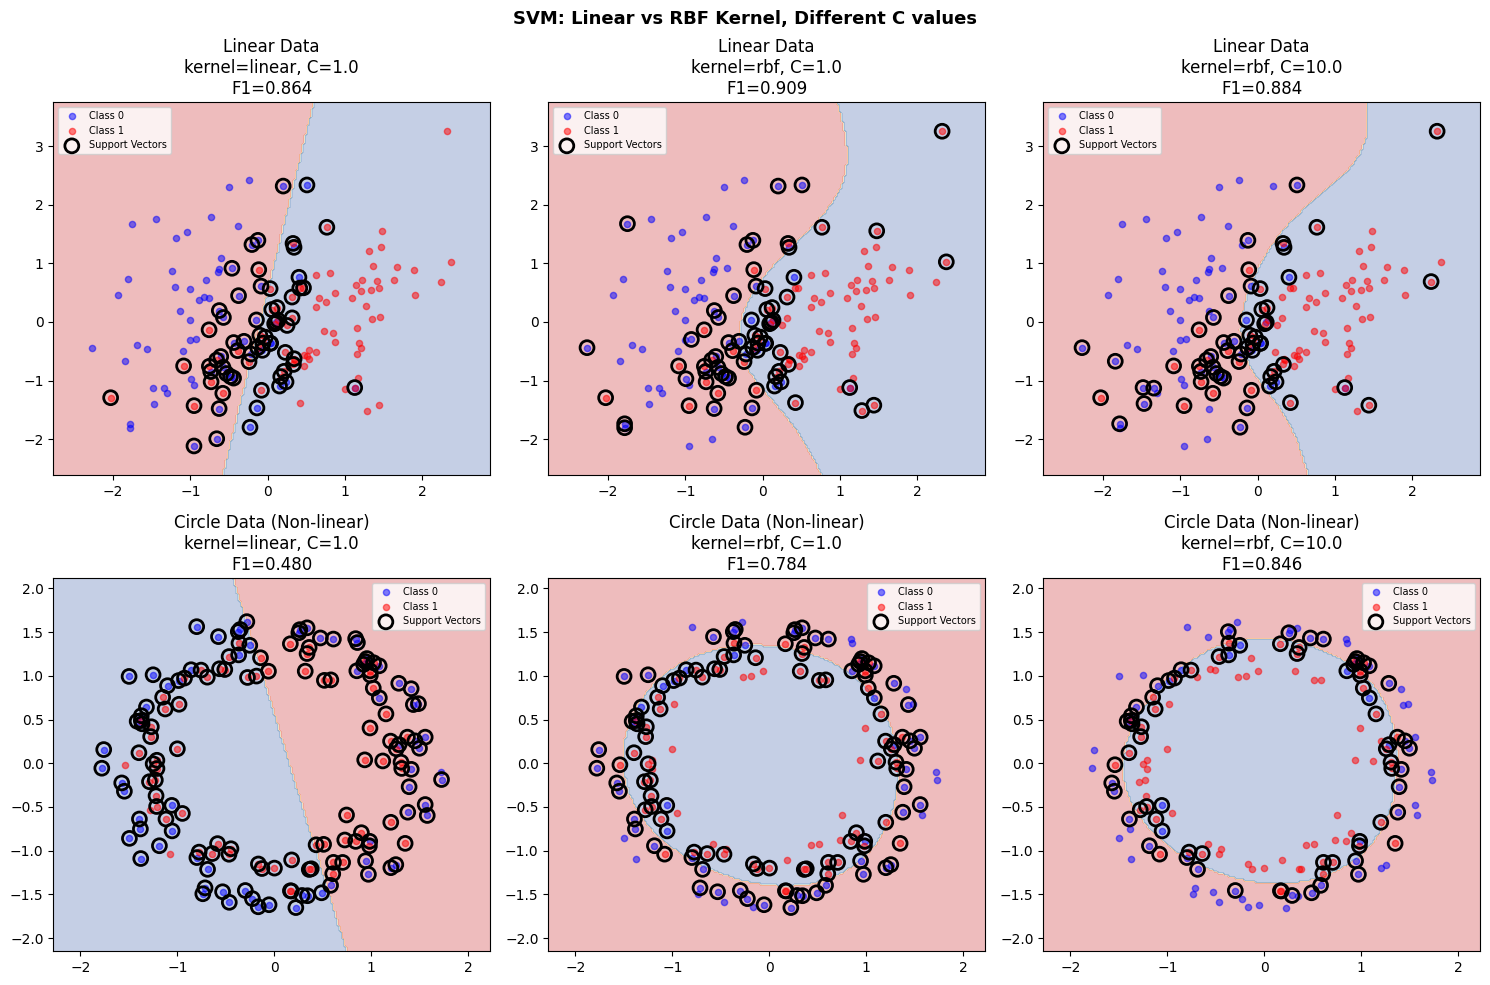

In [1]:
# ============================================================
# BÀI TẬP 1: SVM — Visualize decision boundary
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

# --- Dataset 1: Linearly separable ---
X_lin, y_lin = make_classification(
    n_samples=200, n_features=2, n_redundant=0,
    n_clusters_per_class=1, random_state=42
)

# --- Dataset 2: Non-linear (circles) ---
X_circ, y_circ = make_circles(n_samples=200, noise=0.1, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (X, y, title) in enumerate([
    (X_lin, y_lin, "Linear Data"),
    (X_circ, y_circ, "Circle Data (Non-linear)")
]):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    for col, (kernel, C) in enumerate([
        ('linear', 1.0),
        ('rbf', 1.0),
        ('rbf', 10.0),
    ]):
        svm = SVC(kernel=kernel, C=C, random_state=42)
        svm.fit(X_train_s, y_train)
        f1 = f1_score(y_test, svm.predict(X_test_s))

        ax = axes[row, col]

        # Plot decision boundary
        xx, yy = np.meshgrid(
            np.linspace(X_train_s[:,0].min()-0.5, X_train_s[:,0].max()+0.5, 200),
            np.linspace(X_train_s[:,1].min()-0.5, X_train_s[:,1].max()+0.5, 200)
        )
        Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')

        ax.scatter(X_train_s[y_train==0, 0], X_train_s[y_train==0, 1],
                   c='blue', alpha=0.5, s=20, label='Class 0')
        ax.scatter(X_train_s[y_train==1, 0], X_train_s[y_train==1, 1],
                   c='red', alpha=0.5, s=20, label='Class 1')

        # Highlight support vectors
        sv = svm.support_vectors_
        ax.scatter(sv[:,0], sv[:,1], s=100, facecolors='none',
                   edgecolors='black', linewidth=2, label='Support Vectors')

        ax.set_title(f"{title}\nkernel={kernel}, C={C}\nF1={f1:.3f}")
        ax.legend(fontsize=7)

plt.suptitle("SVM: Linear vs RBF Kernel, Different C values", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("bai_tap_1_svm.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# NHẬN XÉT (viết sau khi chạy)
# ============================================================
# Linear kernel trên Circle data: F1 cao hay thấp? Tại sao? → [điền]
# RBF kernel trên Circle data: Tốt hơn không? Tại sao? → [điền]
# C lớn hơn ảnh hưởng gì đến decision boundary? → [điền]

Model                 Accuracy      F1     AUC     CV F1
----------------------------------------------------------
Random Forest           0.8212  0.7576  0.8352    0.7200
XGBoost                 0.8045  0.7328  0.8246    0.7584


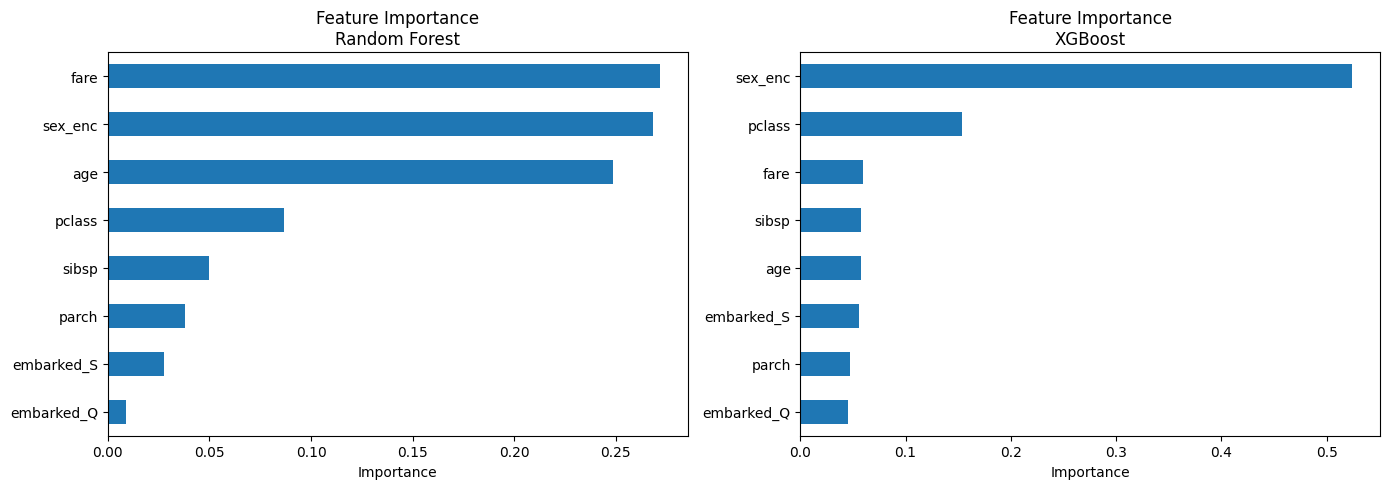

In [3]:
# ============================================================
# BÀI TẬP 2: XGBoost vs Random Forest — Titanic
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import xgboost as xgb

# --- Load và preprocess Titanic ---
df = sns.load_dataset('titanic')
df_model = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()
df_model['age']      = df_model['age'].fillna(df_model['age'].median())
df_model['embarked'] = df_model['embarked'].fillna(df_model['embarked'].mode()[0])
df_model['fare']     = df_model['fare'].fillna(df_model['fare'].median())
df_model['sex_enc']  = (df_model['sex'] == 'female').astype(int)
df_model = pd.get_dummies(df_model, columns=['embarked'], drop_first=True)
df_model = df_model.drop(columns=['sex'])

X = df_model.drop(columns=['survived'])
y = df_model['survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Train models ---
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

rf.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# --- So sánh metrics ---
models = {'Random Forest': rf, 'XGBoost': xgb_model}

print(f"{'Model':<20}{'Accuracy':>10}{'F1':>8}{'AUC':>8}{'CV F1':>10}")
print("-" * 58)

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    cv_f1  = cross_val_score(model, X_train, y_train, cv=5, scoring='f1').mean()

    print(f"{name:<20}{accuracy_score(y_test,y_pred):>10.4f}"
          f"{f1_score(y_test,y_pred):>8.4f}"
          f"{roc_auc_score(y_test,y_prob):>8.4f}"
          f"{cv_f1:>10.4f}")

# --- Feature Importance so sánh ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, models.items()):
    fi = pd.Series(model.feature_importances_, index=X.columns)
    fi.sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f"Feature Importance\n{name}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig("bai_tap_2_rf_vs_xgb.png", dpi=150)
plt.show()

# ============================================================
# NHẬN XÉT (viết sau khi chạy)
# ============================================================
# XGBoost hay RF tốt hơn trên Titanic? Về F1? Về AUC? → [điền]
# Feature quan trọng nhất theo mỗi model là gì? Có khác nhau không? → [điền]
# CV F1 và Test F1 có gần nhau không? → [điền]


Config                  Train F1   Test F1     Gap
----------------------------------------------------
lr=0.3, n=50              1.0000    0.8995  0.1005 ← overfit!
lr=0.3, n=200             1.0000    0.8986  0.1014 ← overfit!
lr=0.1, n=50              0.9807    0.9000  0.0807 ← overfit!
lr=0.1, n=200             1.0000    0.9010  0.0990 ← overfit!
lr=0.01, n=200            0.9531    0.9045  0.0486
lr=0.01, n=1000           1.0000    0.9118  0.0882 ← overfit!


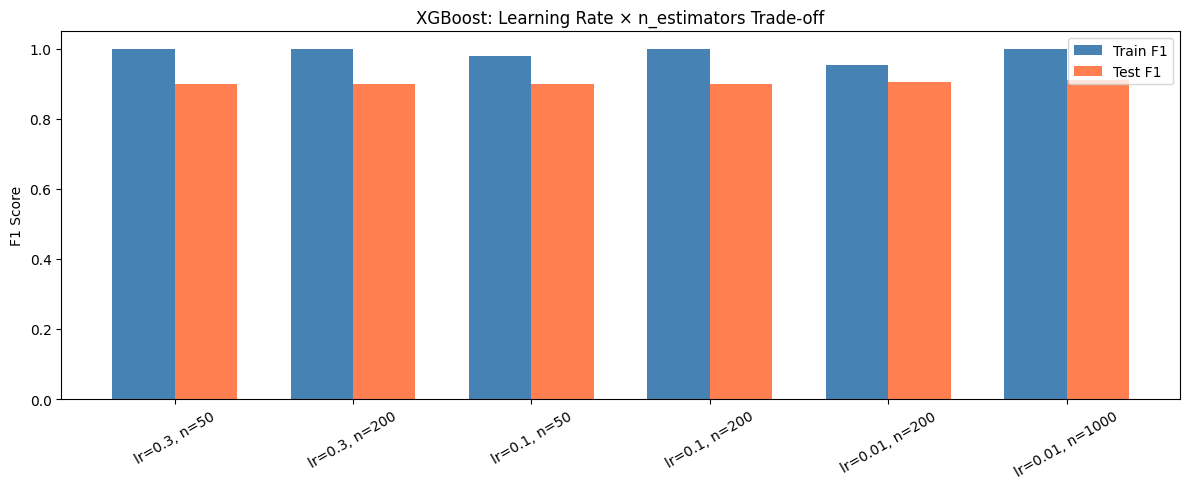

In [4]:
# ============================================================
# BÀI TẬP 3: Hiểu Learning Rate và n_estimators
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Thử các combinations learning_rate × n_estimators
configs = [
    (0.3,  50,  'lr=0.3, n=50'),
    (0.3,  200, 'lr=0.3, n=200'),
    (0.1,  50,  'lr=0.1, n=50'),
    (0.1,  200, 'lr=0.1, n=200'),
    (0.01, 200, 'lr=0.01, n=200'),
    (0.01, 1000,'lr=0.01, n=1000'),
]

print(f"{'Config':<22}{'Train F1':>10}{'Test F1':>10}{'Gap':>8}")
print("-" * 52)

results = []
for lr, n, label in configs:
    model = xgb.XGBClassifier(
        learning_rate=lr, n_estimators=n,
        max_depth=4, random_state=42,
        eval_metric='logloss', verbosity=0
    )
    model.fit(X_train, y_train)
    train_f1 = f1_score(y_train, model.predict(X_train))
    test_f1  = f1_score(y_test,  model.predict(X_test))
    gap = train_f1 - test_f1
    results.append((label, train_f1, test_f1, gap))
    flag = " ← overfit!" if gap > 0.05 else ""
    print(f"{label:<22}{train_f1:>10.4f}{test_f1:>10.4f}{gap:>8.4f}{flag}")

# --- Visualize ---
labels  = [r[0] for r in results]
train_f = [r[1] for r in results]
test_f  = [r[2] for r in results]

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(12, 5))
plt.bar(x - width/2, train_f, width, label='Train F1', color='steelblue')
plt.bar(x + width/2, test_f,  width, label='Test F1',  color='coral')
plt.xticks(x, labels, rotation=30)
plt.ylabel("F1 Score")
plt.title("XGBoost: Learning Rate × n_estimators Trade-off")
plt.legend()
plt.tight_layout()
plt.savefig("bai_tap_3_lr_nestimators.png", dpi=150)
plt.show()

# ============================================================
# NHẬN XÉT (viết sau khi chạy)
# ============================================================
# lr=0.3, n=50 vs lr=0.01, n=1000: Test F1 khác nhau thế nào? → [điền]
# Combination nào cho kết quả tốt nhất? → [điền]
# Tại sao lr nhỏ hơn thường cần nhiều n_estimators hơn? → [điền]